# Data Challenge (Hackathon) - Bäckerei Umsatz

## 1. Problembeschreibung

- Worum geht es?
- Welche Daten werden verwendet?

### Daten

Die Basis für diese Challenge bildet der Datensatz **Umsatz_Baeckerei.csv**. Der Datensatz enthält die täglichen Umsätze einer **Bäckereifiliale in Kiel** (Schleswig-Holstein) für 6 verschiedene Warengruppen:

- 1 - Brot
- 2 - Brötchen
- 3 - Croissants
- 4 - Konditorei
- 5 - Kuchen
- 6 - unbekannt

**Hinweis:** Die Daten für Warengruppe 6 sind jedoch unvollständig und sollen im weiteren Verlauf nicht berücksichtigt werden. Um die Problemstellung einzugrenzen, betrachten wir für diese Challenge nur die beiden umsatzstärksten Warengruppen 2 (Brötchen) und 5 (Kuchen).

Die Umsätze liegen im Zeitraum 01.07.2013 bis 30.07.2019 vor.
- Die Daten für die Jahre 2013 bis 2017 können als **Trainingsdaten** verwendet werden.
- Die Daten für 2018 sind als **Testdaten** reserviert.
- Die Daten für 2019 werden nicht verwendet.

### Ziel

Das Ziel der Challenge ist es, das beste Prognosemodell für die Warengruppen 2 (Brötchen) und 5 (Kuchen) zu finden.

In [213]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [214]:
# CSV-Datei einlesen
df = pd.read_csv("../../data/raw/Umsatz_Baeckerei.csv")

# Ersten Zeilen anzeigen
df.head()

,Datum,Warengruppe,Umsatz
0,2013-07-01,1,148.828353
1,2013-07-02,1,159.793757
2,2013-07-03,1,111.885594
3,2013-07-04,1,168.864941
4,2013-07-05,1,171.280754


In [215]:
# Überblick über den Datensatz
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11164 entries, 0 to 11163
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Datum        11164 non-null  object 
 1   Warengruppe  11164 non-null  int64  
 2   Umsatz       11164 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 261.8+ KB


In [216]:
# Formatierung anpassen
df["Datum"] = pd.to_datetime(df["Datum"])
df["Umsatz"] = df["Umsatz"].round(2)
df.head()

,Datum,Warengruppe,Umsatz
0,2013-07-01,1,148.83
1,2013-07-02,1,159.79
2,2013-07-03,1,111.89
3,2013-07-04,1,168.86
4,2013-07-05,1,171.28


In [217]:
# Datensatz auf Warengruppen 2 und 5 einschränken
df = df[df["Warengruppe"].isin([2, 5])].copy()

# Spalte umbenennen
df = df.rename(columns={"Warengruppe": "Warengruppe_num"})

# Textuelle Warengruppen ergänzen
warengruppe_mapping = {
    2: "Brötchen",
    5: "Kuchen"
}

df["Warengruppe_text"] = df["Warengruppe_num"].map(warengruppe_mapping)

# Datumsgrenze definieren
stichtag = pd.to_datetime("2019-01-01")

# Datensatz auf Daten vor dem gewählten Stichtag filtern
df = df[df["Datum"] < stichtag].copy()

# Ergebnis prüfen
df.head()

,Datum,Warengruppe_num,Umsatz,Warengruppe_text
2174,2013-07-01,2,535.86,Brötchen
2175,2013-07-02,2,546.78,Brötchen
2176,2013-07-03,2,427.34,Brötchen
2177,2013-07-04,2,454.86,Brötchen
2178,2013-07-05,2,492.82,Brötchen


In [218]:
# Extremwerte in H1 2014 glätten (Capping auf IQR-basierte Obergrenze)
# Betroffener Zeitraum: 01.01.2014 – 30.06.2014
# Besonders auffällig: 05.05.2014 mit Brötchen=1203 EUR, Kuchen=749 EUR

h1_2014_mask = (df["Datum"] >= "2014-01-01") & (df["Datum"] <= "2014-06-30")

for wg in df["Warengruppe_text"].unique():
    wg_mask = df["Warengruppe_text"] == wg

    # Obergrenze auf Basis der Gesamtdaten berechnen (Q75 + 1.5 * IQR)
    q25 = df.loc[wg_mask, "Umsatz"].quantile(0.25)
    q75 = df.loc[wg_mask, "Umsatz"].quantile(0.75)
    iqr = q75 - q25
    upper_bound = q75 + 1.5 * iqr

    # Nur in H1 2014: Werte über der Obergrenze auf die Obergrenze setzen
    clip_mask = h1_2014_mask & wg_mask & (df["Umsatz"] > upper_bound)
    n_clipped = clip_mask.sum()
    print(f"{wg}: {n_clipped} Werte gekappt auf {upper_bound:.2f} EUR")
    df.loc[clip_mask, "Umsatz"] = upper_bound

print(f"\nGesamt: {df.loc[h1_2014_mask].shape[0]} Datensätze in H1 2014")

Brötchen: 3 Werte gekappt auf 792.38 EUR
Kuchen: 6 Werte gekappt auf 427.63 EUR

Gesamt: 352 Datensätze in H1 2014


## 2. Explorative Datenanalyse / Aufbereitung des Datensatzes

- Was steckt in den Daten? (explorative Datenanalyse, Visualisierung der Erkenntnisse)
- Welche Besonderheiten gibt es? (Outlier, Missing Values,…)
- Wie werden die Daten aufbereitet? (Anreicherung mit externen Daten, Feature Engineering,…)
- Welche Features werden verwendet?
- Wie ist die Aufteilung der Daten? (Train/Test Split, optional: Evaluation Data)

In [219]:
# Grundlegender Überblick
print("Shape des Datensatzes:")
print(df.shape)

print("\nDatentypen:")
print(df.dtypes)

print("\nStatistische Kennzahlen je Warengruppe:")
display(
    df.groupby("Warengruppe_text")["Umsatz"].describe()
)

# Missing Values
print("\nFehlende Werte pro Spalte:")
print(df.isnull().sum())

print("\nAnzahl der Datensätze mit Umsatz = 0 je Warengruppe:")
print(
    df[df["Umsatz"] == 0]
    .groupby("Warengruppe_text")
    .size()
)

Shape des Datensatzes:
(3938, 4)

Datentypen:
Datum               datetime64[ns]
Warengruppe_num              int64
Umsatz                     float64
Warengruppe_text            object
dtype: object

Statistische Kennzahlen je Warengruppe:


,count,mean,std,min,25%,50%,75%,max
Warengruppe_text,,,,,,,,
Brötchen,1969.0,401.704068,136.829753,175.00,289.53,371.97,490.67,930.80
Kuchen,1969.0,277.471204,101.274510,121.49,229.43,266.70,308.71,1879.46



Fehlende Werte pro Spalte:
Datum               0
Warengruppe_num     0
Umsatz              0
Warengruppe_text    0
dtype: int64

Anzahl der Datensätze mit Umsatz = 0 je Warengruppe:
Series([], dtype: int64)


Es gibt also keine fehlenden Werte. Das heißt, für jedes enthaltene Datum sind alle Spalten gefüllt.

**ACHTUNG:** Trotzdem kann es Datümer gehen, die im Datensatz nicht auftauchen. Das sollten wir überprüfen!

In [220]:
# Fehlende Datümer in der Zeitreihe
pd.date_range(df["Datum"].min(), df["Datum"].max()).difference(df["Datum"])

DatetimeIndex(['2013-12-25', '2013-12-26', '2013-12-28', '2014-01-01',
               '2014-04-18', '2014-05-01', '2014-05-03', '2014-05-04',
               '2014-08-17', '2014-12-25', '2014-12-26', '2015-01-01',
               '2015-04-03', '2015-05-01', '2015-12-25', '2015-12-26',
               '2016-01-01', '2016-03-24', '2016-03-25', '2016-07-07',
               '2016-07-18', '2016-08-14', '2016-08-15', '2016-12-17',
               '2016-12-25', '2016-12-26', '2017-01-01', '2017-04-14',
               '2017-05-01', '2017-07-04', '2017-10-23', '2017-10-31',
               '2017-12-25', '2017-12-26', '2018-01-01', '2018-03-30',
               '2018-05-01', '2018-05-21', '2018-10-31', '2018-12-25',
               '2018-12-26'],
              dtype='datetime64[ns]', freq=None)

In [221]:
# Fehlende Tage füllen (Feiertage/geschlossen)
date_range = pd.date_range(df['Datum'].min(), df['Datum'].max(), freq='D')
df_filled = []
for wg in df['Warengruppe_num'].unique():
    df_wg = df[df['Warengruppe_num'] == wg].set_index('Datum').reindex(date_range)
    df_wg['ist_geschlossen'] = df_wg['Umsatz'].isna().astype(int)
    df_wg['Umsatz'] = df_wg['Umsatz'].fillna(0)
    df_wg['Warengruppe_num'] = wg
    # Populate Warengruppe_text
    wg_text = warengruppe_mapping.get(wg, None)
    df_wg['Warengruppe_text'] = wg_text
    df_filled.append(df_wg.reset_index().rename(columns={'index': 'Datum'}))
df = pd.concat(df_filled, ignore_index=True).sort_values(['Warengruppe_num', 'Datum']).reset_index(drop=True)

print(f"Geschlossene Tage gefüllt: {df['ist_geschlossen'].sum()}")
print(f"Keine Lücken mehr: {len(df[df['ist_geschlossen'] == 1])} Tage mit Umsatz=0")

Geschlossene Tage gefüllt: 82
Keine Lücken mehr: 82 Tage mit Umsatz=0


### Erkenntnisse aus der explorativen Datenanalyse (Teil 1)

- Für beide Warengruppen (Brötchen und Kuchen) liegen je 1.969 Beobachtungen vor.
- Es gibt zwar keine fehlenden Werte: Für jedes existierende Datum sind alle Spalten gefüllt.
- Aber für einige Datümer liegen keine Umsatzdaten vor. Dabei handelt es sich auf den ersten Blick um Feiertage, an denen die Bäckereifiliale geschlossen war. Es sind also keine klassischen *missing values*.
- Der durchschnittliche Umsatz für Brötchen (402 EUR / Tag) liegt über dem für Kuchen (278 EUR / Tag).
- Bei beiden Warengruppen liegt der Mittelwert über dem Median, ein Hinweis auf eine rechtsschiefe Verteilungen (einige Tage mit sehr hohen Umsätzen).
- Die Umsätze für Brötchen zeigen eine größere Volatilität (Streuung).
- Die Umsätze für Kuchen zeigen extreme Ausreißer nach oben, trotz niedrigerem Durchschnitt, im Vergleich zu den Umsätzen für Brötchen. --> Das sollten wir genauer untersuchen! (Outlier?)
- Beide Warengruppen haben relativ niedrige Mindestumsätze, ein Hinweis auf mögliche Sondertage (Feiertage, Schließungen, Datenartefakte).

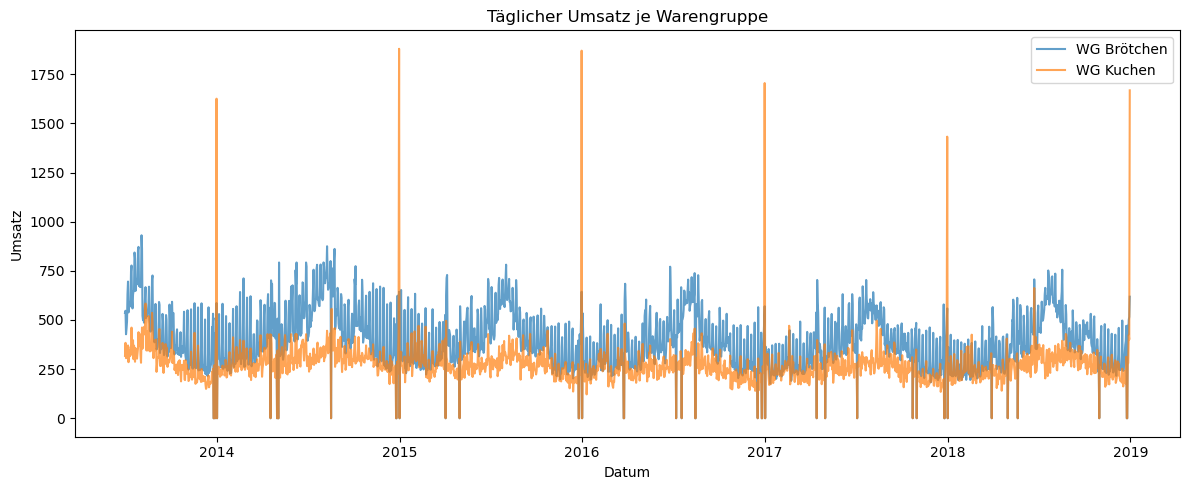

In [222]:
# Zeitlicher Verlauf
plt.figure(figsize=(12, 5))
for wg in sorted(df["Warengruppe_text"].unique()):
    subset = df[df["Warengruppe_text"] == wg]
    plt.plot(subset["Datum"], subset["Umsatz"], label=f"WG {wg}", alpha=0.7)

plt.title("Täglicher Umsatz je Warengruppe")
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.legend()
plt.tight_layout()
plt.show()

### Erkenntnisse aus der explorativen Datenanalyse (Teil 2)

- Im zeitlichen Verlauf sehen wir saisonale Muster für beide Warengruppen.
- Die Umsätze im Sommer scheinen tendenziell höher zu sein (Ferien?).
- Die saisonalen Schwankungen sind für Brötchen stärker ausgeprägt im Vergleich zu Kuchen.
- Die Umsätze für Kuchen zeigen Extremwerte zum Jahresende (Berliner?).
- Es gibt einen ungewöhnlichen Peek für beide Warengruppen im Mai 2014 (--> Artefakt?!)

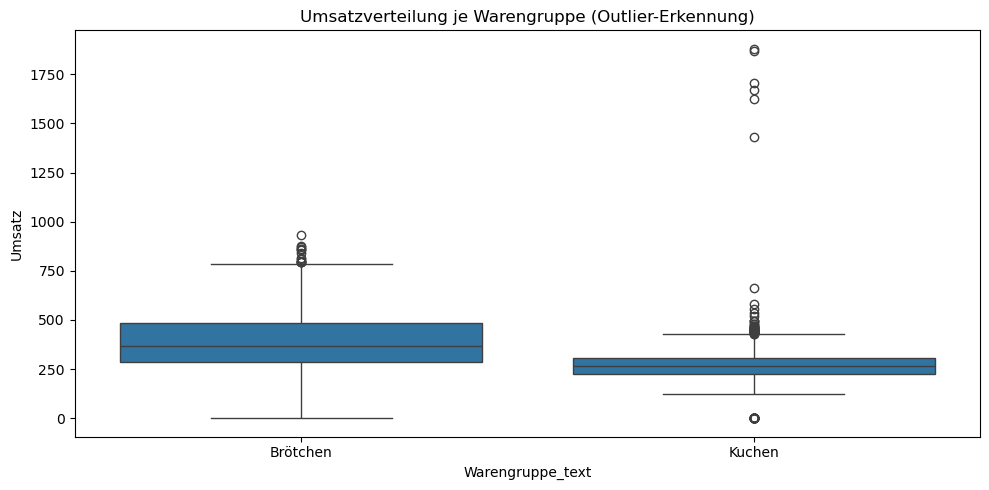

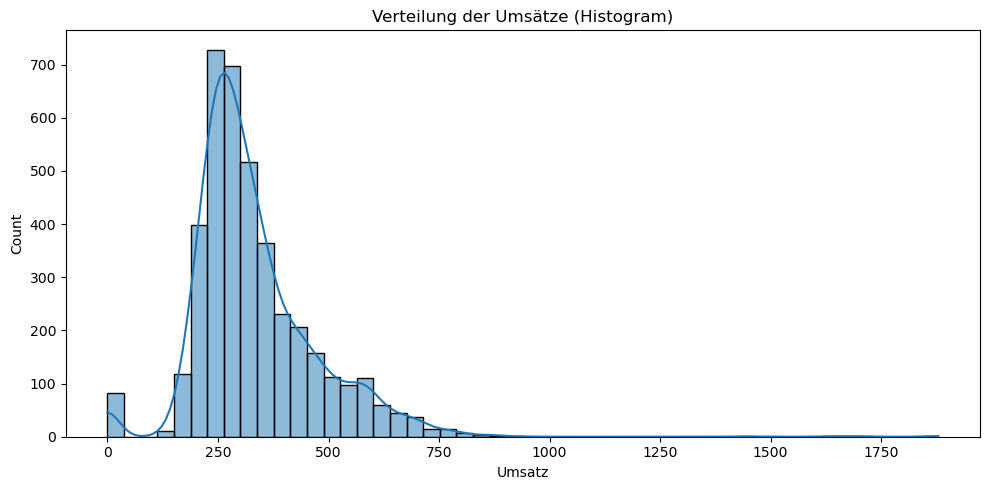

,Datum,Umsatz
2558,2014-12-31,1879.46
2923,2015-12-31,1869.94
3289,2016-12-31,1705.14
4019,2018-12-31,1668.12
2193,2013-12-31,1625.69


In [223]:
# Verteilungen & Outlier
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Warengruppe_text", y="Umsatz")
plt.title("Umsatzverteilung je Warengruppe (Outlier-Erkennung)")
plt.tight_layout()
plt.show()

# Histogramm Umsatz
plt.figure(figsize=(10, 5))
sns.histplot(df["Umsatz"], bins=50, kde=True)
plt.title("Verteilung der Umsätze (Histogram)")
plt.xlabel("Umsatz")
plt.tight_layout()
plt.show()

# TOP5 umsatzstärkste Tage für die Warengruppe "Kuchen"
top5_kuchen = (
    df[df["Warengruppe_text"] == "Kuchen"]
    .sort_values(by="Umsatz", ascending=False)
    .head(5)
)

display(top5_kuchen[["Datum", "Umsatz"]])

### Erkenntnisse aus der explorativen Datenanalyse (Teil 3)

Analyse des **Boxplots**:

- Ausgefüllte Box zeigt den Normalbereich der Umsätze (25% Quartil - 75% Quartil).
- Die Linie innerhalb der ausgefüllten Box zeigt den Median (50%).
- Die Whisker zeigen die Range für Werte bis 1,5 x IQR (Interquartilsbereich, also der Abstand zwischen 25% und 75% Quartil).
- Punkte außerhalb der Whisker sind "Ausreißer".

Analyse der **Umsatzverteilung**:

-  Wir finden - wie erwartet - eine rechtsschiefe Verteilungen: Es gibt einige wenige Tage mit sehr hohen Umsätzen.
- Die TOP5 umsatzstärksten Tage für Kuchen sind die Silvestertage. Hier spiegelt sich offenbar der Berliner-Verkauf wider. Das sollten wir für unsere Prognosemodelle im Hinterkopf behalten!

## Anreicherung der Daten

Es ist für diese Challenge zulässig, die originären Daten anzureichern. Es gibt verschiedene Arten, Daten anzureichern, z.B. auf Basis vorhandener Informationen oder mithilfe von externen Informationen.

Beispiele für vorhandene Informationen sind:
- Wochentag / Monat
- Umsatz der Vortage (lag_1d, lag_2d, ...)
- Umsatz des entsprechenden Wochentages der Vorwochen (lag_1W, lag_2W, ...)
- Umsatz des entsprechenden Tages des Vorjahres (lag_1y)
- Durchschnittlicher Umsatz der letzten 3 Tage (mean_3d)
- ...

Beispiele für externe Informationen könnten sein:

- Schulferien (saisongeschäft vor allem im Sommer sichtbar mit starken Umsätzen)
- Feiertage (vor allem Silvester)
- (Groß-)Veranstaltungen (Kieler Woche)
- Wetterdaten (Temperatur, Niederschlag, Sonnenscheindauer,...)
- ...

**Hinweise:**

- Wenn Ihr die Daten anreichert, müsst Ihr sicherstellen, dass auch die Testdaten (Jahresscheibe 2018) entsprechend angereichert werden.
- Und gebt unbedingt die Quellen für verwendete externe Daten an.

### Demo

- Exemplarisch werden hier die Daten um eine einfache Dummy-Variable "Silvester" angereichert. Die Variable hat den Wert 1 an Silvester und 0 sonst.
- Außerdem schaffen wir für die Wochentage (Montag - Sonntag) weitere Dummy-Variablen mit Ausprägung 0/1.
- Und wir bilden den Umsatz des entsprechenden Wochentages der Vorwoche als neues numerisches Input Feature (lag_1W).

In [224]:
# 0/1-Variable "Silvester" erzeugen
df["Silvester"] = (
    (df["Datum"].dt.month == 12) &
    (df["Datum"].dt.day == 31)
).astype(int)

df.groupby("Warengruppe_text")["Silvester"].value_counts()

Warengruppe_text  Silvester
Brötchen          0            2004
                  1               6
Kuchen            0            2004
                  1               6
Name: count, dtype: int64

In [225]:
# Wochentag als Text (Montag, Dienstag, ...)
df["Wochentag_num"] = df["Datum"].dt.weekday

wochentag_mapping = {
    0: "Montag",
    1: "Dienstag",
    2: "Mittwoch",
    3: "Donnerstag",
    4: "Freitag",
    5: "Samstag",
    6: "Sonntag"
}

df["Wochentag"] = df["Wochentag_num"].map(wochentag_mapping)

# Dummy-Variablen erzeugen
wochentag_dummies = pd.get_dummies(
    df["Wochentag"],
    prefix="WT",
    drop_first=False # <-- Brauche eigentlich nur 6 Wochentags-Variablen
)

# Dummies an Datensatz anhängen
df = pd.concat([df, wochentag_dummies], axis=1)

# Alle Wochentags-Dummies von bool → 0/1 umwandeln
wt_cols = [col for col in df.columns if col.startswith("WT_")]
df[wt_cols] = df[wt_cols].astype(int)

In [226]:
# ============================================================
# Externe Daten einlesen und als Features an df anhängen
# ============================================================
ext_path = "../../data/external_factors/"

# --- 1. Ferien (Schulferien Schleswig-Holstein) → Dummy 0/1 ---
df_ferien = pd.read_csv(ext_path + "ferien.csv")
df_ferien["Start"] = pd.to_datetime(df_ferien["Start"], errors="coerce")
df_ferien["Ende"] = pd.to_datetime(df_ferien["Ende"], errors="coerce")
df_ferien = df_ferien.dropna(subset=["Start", "Ende"])

ferien_tage = set()
for _, row in df_ferien.iterrows():
    ferien_tage.update(pd.date_range(row["Start"], row["Ende"]))

df["Ferien"] = df["Datum"].isin(ferien_tage).astype(int)
print(f"Ferien: {df['Ferien'].sum() // 2} Ferientage erkannt (je WG)")

# --- 2. Kieler Woche → Dummy 0/1 ---
df_kw = pd.read_csv(ext_path + "kieler_woche.csv")
df_kw["Start"] = pd.to_datetime(df_kw["Start"])
df_kw["Ende"] = pd.to_datetime(df_kw["Ende"])

kw_tage = set()
for _, row in df_kw.iterrows():
    kw_tage.update(pd.date_range(row["Start"], row["Ende"]))

df["KielerWoche"] = df["Datum"].isin(kw_tage).astype(int)
print(f"Kieler Woche: {df['KielerWoche'].sum() // 2} Tage erkannt (je WG)")

# --- 3. Niederschlag (monatlich) → numerisch ---
df_niederschlag = pd.read_csv(ext_path + "niederschlag.csv")
df_niederschlag[["_j", "_m"]] = df_niederschlag["category"].str.split("/", expand=True)
df_niederschlag["_j"] = df_niederschlag["_j"].astype(int)
df_niederschlag["_m"] = df_niederschlag["_m"].astype(int)
df_niederschlag["Niederschlag"] = df_niederschlag["Niederschlag"].replace(-999, np.nan).interpolate()

# Lookup-Dict: (Jahr, Monat) → Niederschlag
niederschlag_map = dict(zip(
    zip(df_niederschlag["_j"], df_niederschlag["_m"]),
    df_niederschlag["Niederschlag"]
))

df["Niederschlag"] = list(zip(df["Datum"].dt.year, df["Datum"].dt.month))
df["Niederschlag"] = df["Niederschlag"].map(niederschlag_map)

# --- 4. Sonnenscheindauer (monatlich) → numerisch ---
df_sonne = pd.read_csv(ext_path + "sonnenscheindauer.csv")
df_sonne[["_j", "_m"]] = df_sonne["category"].str.split("/", expand=True)
df_sonne["_j"] = df_sonne["_j"].astype(int)
df_sonne["_m"] = df_sonne["_m"].astype(int)
df_sonne["Sonnenschein"] = df_sonne["Sonnenschein"].replace(-999, np.nan).interpolate()

sonnenschein_map = dict(zip(
    zip(df_sonne["_j"], df_sonne["_m"]),
    df_sonne["Sonnenschein"]
))

df["Sonnenschein"] = list(zip(df["Datum"].dt.year, df["Datum"].dt.month))
df["Sonnenschein"] = df["Sonnenschein"].map(sonnenschein_map)

# --- 5. Temperatur (monatlich, Mittelwert) → numerisch ---
df_temp = pd.read_csv(ext_path + "temperatur.csv")
df_temp[["_j", "_m"]] = df_temp["category"].str.split("/", expand=True)
df_temp["_j"] = df_temp["_j"].astype(int)
df_temp["_m"] = df_temp["_m"].astype(int)
df_temp["Mittelwert"] = pd.to_numeric(df_temp["Mittelwert"], errors="coerce").interpolate()

temperatur_map = dict(zip(
    zip(df_temp["_j"], df_temp["_m"]),
    df_temp["Mittelwert"]
))

df["Temperatur"] = list(zip(df["Datum"].dt.year, df["Datum"].dt.month))
df["Temperatur"] = df["Temperatur"].map(temperatur_map)

# Überblick
print(f"\nNeue Spalten: Ferien, KielerWoche, Niederschlag, Sonnenschein, Temperatur")
print(f"Shape nach Anreicherung: {df.shape}")
print(f"Fehlende Werte in neuen Spalten:")
print(df[["Ferien", "KielerWoche", "Niederschlag", "Sonnenschein", "Temperatur"]].isnull().sum())
df[["Datum", "Warengruppe_text", "Ferien", "KielerWoche", "Niederschlag", "Sonnenschein", "Temperatur"]].sample(10, random_state=42)

Ferien: 502 Ferientage erkannt (je WG)
Kieler Woche: 45 Tage erkannt (je WG)

Neue Spalten: Ferien, KielerWoche, Niederschlag, Sonnenschein, Temperatur
Shape nach Anreicherung: (4020, 20)
Fehlende Werte in neuen Spalten:
Ferien          0
KielerWoche     0
Niederschlag    0
Sonnenschein    0
Temperatur      0
dtype: int64


,Datum,Warengruppe_text,Ferien,KielerWoche,Niederschlag,Sonnenschein,Temperatur
2981,2016-02-27,Kuchen,0,0,85.1,54.1,3.5
1204,2016-10-17,Brötchen,1,0,79.2,52.0,9.8
2720,2015-06-11,Kuchen,0,0,33.6,225.8,14.1
1954,2018-11-06,Brötchen,0,0,20.3,45.5,6.4
1226,2016-11-08,Brötchen,0,0,32.1,54.7,4.6
465,2014-10-09,Brötchen,0,0,54.5,82.3,13.0
2144,2013-11-12,Kuchen,0,0,54.2,62.5,6.1
551,2015-01-03,Brötchen,1,0,131.5,23.3,3.0
838,2015-10-17,Brötchen,0,0,42.7,101.5,9.9
1513,2017-08-22,Brötchen,1,0,61.1,196.1,16.9


In [227]:
df.head()

,Datum,Warengruppe_num,Umsatz,Warengruppe_text,ist_geschlossen,Silvester,Wochentag_num,Wochentag,WT_Dienstag,WT_Donnerstag,WT_Freitag,WT_Mittwoch,WT_Montag,WT_Samstag,WT_Sonntag,Ferien,KielerWoche,Niederschlag,Sonnenschein,Temperatur
0,2013-07-01,2,535.86,Brötchen,0,0,0,Montag,0,0,0,0,1,0,0,1,0,58.0,315.8,18.4
1,2013-07-02,2,546.78,Brötchen,0,0,1,Dienstag,1,0,0,0,0,0,0,1,0,58.0,315.8,18.4
2,2013-07-03,2,427.34,Brötchen,0,0,2,Mittwoch,0,0,0,1,0,0,0,1,0,58.0,315.8,18.4
3,2013-07-04,2,454.86,Brötchen,0,0,3,Donnerstag,0,1,0,0,0,0,0,1,0,58.0,315.8,18.4
4,2013-07-05,2,492.82,Brötchen,0,0,4,Freitag,0,0,1,0,0,0,0,1,0,58.0,315.8,18.4


In [228]:
## Umsatz des gleichen Wochentags der Vorwoche (lag_1W)
# Da es sich um Tagesdaten handelt, entspricht „gleicher Wochentag der Vorwoche“ einem Lag von 7 Tagen,
# sofern dieser vorhanden ist. (Hinweis: Hier wird vereinfachend ignoriert, dass für einige Datümer keine Umsätze vorliegen.)
# Wichtig: Vorher zeitlich sortieren und nach Warengruppe trennen!

# Nach Warengruppe und Datum sortieren
df = df.sort_values(["Warengruppe_text", "Datum"])

# Lag-Feature: Umsatz der Vorwoche (gleicher Wochentag)
df["lag_1W"] = (
    df.groupby("Warengruppe_text")["Umsatz"]
      .shift(7)
)

In [229]:
# Ergebnis prüfen
df[[
    "Datum",
    "Warengruppe_text",
    "Umsatz",
    "lag_1W"
]].head(20)

,Datum,Warengruppe_text,Umsatz,lag_1W
0,2013-07-01,Brötchen,535.86,NaN
1,2013-07-02,Brötchen,546.78,NaN
2,2013-07-03,Brötchen,427.34,NaN
3,2013-07-04,Brötchen,454.86,NaN
4,2013-07-05,Brötchen,492.82,NaN
5,2013-07-06,Brötchen,631.91,NaN
6,2013-07-07,Brötchen,695.26,NaN
7,2013-07-08,Brötchen,538.53,535.86
8,2013-07-09,Brötchen,585.96,546.78
9,2013-07-10,Brötchen,567.37,427.34


In [230]:
# Für die erste Woche des Datensatzes gibt es keine Vorwochenwerte!
df["lag_1W"].isnull().sum()

14

In [231]:
# NaN Werte entfernen (Zeilen löschen)
df = df.dropna().copy()

In [232]:
df.head()

,Datum,Warengruppe_num,Umsatz,Warengruppe_text,ist_geschlossen,Silvester,Wochentag_num,Wochentag,WT_Dienstag,WT_Donnerstag,...,WT_Mittwoch,WT_Montag,WT_Samstag,WT_Sonntag,Ferien,KielerWoche,Niederschlag,Sonnenschein,Temperatur,lag_1W
7,2013-07-08,2,538.53,Brötchen,0,0,0,Montag,0,0,...,0,1,0,0,1,0,58.0,315.8,18.4,535.86
8,2013-07-09,2,585.96,Brötchen,0,0,1,Dienstag,1,0,...,0,0,0,0,1,0,58.0,315.8,18.4,546.78
9,2013-07-10,2,567.37,Brötchen,0,0,2,Mittwoch,0,0,...,1,0,0,0,1,0,58.0,315.8,18.4,427.34
10,2013-07-11,2,569.11,Brötchen,0,0,3,Donnerstag,0,1,...,0,0,0,0,1,0,58.0,315.8,18.4,454.86
11,2013-07-12,2,600.27,Brötchen,0,0,4,Freitag,0,0,...,0,0,0,0,1,0,58.0,315.8,18.4,492.82


## Train/Test Split

Jetzt wollen wir ```df``` trennen in ```df_train``` und ```df_test```, wobei die Daten für 2018 als Testdaten verwendet werden sollen.

Zunächst behalten wir alle Attribute aus ```df```.

In [233]:
# Jahr aus dem Datum extrahieren
df["Jahr"] = df["Datum"].dt.year

# Trainingsdaten: alles vor 2018
df_train = df[df["Jahr"] < 2018].copy()

# Testdaten: genau das Jahr 2018
df_test = df[df["Jahr"] == 2018].copy()

print("Trainingsdaten:")
print("Zeitraum:", df_train["Datum"].min(), "bis", df_train["Datum"].max())
print("Anzahl Zeilen:", len(df_train))

print("\nTestdaten:")
print("Zeitraum:", df_test["Datum"].min(), "bis", df_test["Datum"].max())
print("Anzahl Zeilen:", len(df_test))

Trainingsdaten:
Zeitraum: 2013-07-08 00:00:00 bis 2017-12-31 00:00:00
Anzahl Zeilen: 3276

Testdaten:
Zeitraum: 2018-01-01 00:00:00 bis 2018-12-31 00:00:00
Anzahl Zeilen: 730


## 3. Modellauswahl

Im folgenden werden zwei verschiedene Ansätze als Prognosemodelle betrachtet, die hier kurz diskutiert werden. Die Ergebnisse dienen als **Baseline** für den Hackathon.

### Modell 1: Heuristik „prognostizierter Umsatz = Umsatz der Vorwoche (lag_1W)“

**Modellbeschreibung:** Die Prognose für einen Tag entspricht exakt dem Umsatz des gleichen Wochentages der Vorwoche.

**Warum dieses Modell?**

- Sehr einfache, intuitiv verständliche Baseline
- Nutzt explizit Wochenmuster, die im Einzelhandel typisch sind
- Kein Training notwendig

**Stärken:**

- Extrem einfach & transparent
- Sehr robust bei stabilen Zeitreihen
- Hervorragender Baseline-Vergleich

**Schwächen:**

- Reagiert nicht auf Sonderereignisse (z. B. Silvester)
- Kein Lernen über längere Zeiträume
- Kann systematische Fehler nicht korrigieren

### Modell 2: Lineare Regression

**Modellbeschreibung:** Ein lineares Regressionsmodell mit folgenden Input-Features:

- lag_1W
- Dummy-Variablen für Wochentage
- Dummy-Variable Silvester

**Warum dieses Modell?**

- Klassisches, gut erklärbares ML-Einstiegsmodell
- Verbindet Zeitreihenidee (lag_1W) mit Kalenderfeatures
- Sehr gut interpretierbar

**Stärken:**

- Lernt systematische Abweichungen vom Vorwochenwert
- Modellparameter sind direkt interpretierbar
- Schnell trainiert, stabil, gut für Demo-Zwecke

**Schwächen:**

- Annahme linearer Zusammenhänge
- Keine Interaktionen oder Nichtlinearitäten
- Begrenzte Modellkapazität bei komplexen Mustern

## 4. Modellierung

Sowohl für Modell 1 (Heuristik) als auch für Modell 2 (lineare Regression) verwenden wir die Daten in der vorliegenden Form. Ein weiteres Preprocessing ist hier nicht erforderlich.

**Hinweis:** Allerdings trennen wir die Daten nach Warengruppen, weil wir in der explorativen Datenanalyse unterschiedliche Charakteristika je Warengruppe identifiziert hatten. Wir betrachten daher getrennte Prognosemodelle für Brötchen und Kuchen.

Die **Zielvariable** ist der Umsatz, den wir prognostizieren wollen.

In [234]:
# Auswahl Input-Features (für lineare Regression)
feature_cols = [
    "Silvester",
    "WT_Dienstag",
    "WT_Donnerstag",
    "WT_Freitag",
    "WT_Mittwoch",
    "WT_Montag",
    "WT_Samstag",
    "WT_Sonntag",
    "lag_1W",
    # Externe Features
    "Ferien",
    "KielerWoche",
    "Niederschlag",
    "Sonnenschein",
    "Temperatur"
]

# Warengruppe 2 – Brötchen
df_train_WG2 = df_train[df_train["Warengruppe_num"] == 2]
df_test_WG2  = df_test[df_test["Warengruppe_num"] == 2]

X_train_WG2 = df_train_WG2[feature_cols]
y_train_WG2 = df_train_WG2["Umsatz"]

X_test_WG2 = df_test_WG2[feature_cols]
y_test_WG2 = df_test_WG2["Umsatz"]

# Heuristik
y_pred_heuristik_WG2 = df_test_WG2["lag_1W"]

# Lineare Regression
lin_reg_WG2 = LinearRegression()
lin_reg_WG2.fit(X_train_WG2, y_train_WG2)

y_pred_lr_WG2 = lin_reg_WG2.predict(X_test_WG2)

# Warengruppe 5 – Kuchen
df_train_WG5 = df_train[df_train["Warengruppe_num"] == 5]
df_test_WG5  = df_test[df_test["Warengruppe_num"] == 5]

X_train_WG5 = df_train_WG5[feature_cols]
y_train_WG5 = df_train_WG5["Umsatz"]

X_test_WG5 = df_test_WG5[feature_cols]
y_test_WG5 = df_test_WG5["Umsatz"]

# Heuristik
y_pred_heuristik_WG5 = df_test_WG5["lag_1W"]

# Lineare Regression
lin_reg_WG5 = LinearRegression()
lin_reg_WG5.fit(X_train_WG5, y_train_WG5)

y_pred_lr_WG5 = lin_reg_WG5.predict(X_test_WG5)

## 5. Evaluation und Diskussion der Ergebnisse

### Metriken

Nachdem wir unsere Baseline-Modelle trainiert haben bzw. die Modellvorhersagen erhalten haben, wollen wir die Prognosegüte bewerten. In der explorativen Datenanalyse hatten wir gesehen, dass es für die Warengruppe 5 (Kuchen) einzelne Tage mit extrem hohen Umsätzen gibt (Silvester). Für diese Tage ist eine gute Prognose daher besonders wichtig.

Für die Warengruppe 2 (Brötchen) habe haben wir in der explorativen Datenanalyse gesehen, dass es zwar keine extremen Ausreißer gibt, aber dafür stärkere saisonale Schwankungen im Jahresverlauf.

Als Metrik verwenden wir daher vorrangig den **root mean squared error** (RMSE).

**Definition:** Quadratischer Fehler, gemittelt und anschließend die Wurzel daraus

$$
\mathrm{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 }
$$

**Interpretation:**

- Einheit ist dieselbe wie der Umsatz (Euro)
- Große Fehler wirken überproportional stark
- Hebt extreme Fehlprognosen hervor
- Sehr verbreitet in Prognose- und Zeitreihenproblemen
- Gut geeignet, wenn Ausreißer besonders schmerzhaft sind

**Nachteile:**

- Stärker verzerrt durch einzelne extreme Tage
- Weniger intuitiv als MAE

**Wichtig:** Für das Ranking der Modelle in der Rangliste ist der RMSE entscheidend!

Daneben betrachten wir den **mean absolute error** (MAE).

**Definition:** Der durchschnittliche absolute Fehler zwischen Prognose und tatsächlichem Wert

$$
\mathrm{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

**Interpretation:**

- Einheit ist dieselbe wie der Umsatz (Euro)
- Gibt an: „Wie viele Euro liegen wir im Schnitt daneben?“
- Sehr robust gegenüber Ausreißern
- Leicht verständlich
- Passt manchmal gut zu geschäftlichen Fragestellungen

**Nachteile:**

- Große Fehler werden nicht stärker bestraft als kleine Abweichungen

**Wichtig:** Den MAE betrachten wir als Begleitmetrik. Der Wert ist für das Ranking der Modelle aber nicht entscheidend.

In [235]:
# Berechne mean absolute error (mae)
mae_heuristik_WG2 = mean_absolute_error(y_test_WG2, y_pred_heuristik_WG2)
mae_lr_WG2 = mean_absolute_error(y_test_WG2, y_pred_lr_WG2)
mae_heuristik_WG5 = mean_absolute_error(y_test_WG5, y_pred_heuristik_WG5)
mae_lr_WG5 = mean_absolute_error(y_test_WG5, y_pred_lr_WG5)

# Berechne root mean squarred error (rmse)
rmse_heuristik_WG2 = np.sqrt(mean_squared_error(y_test_WG2, y_pred_heuristik_WG2))
rmse_lr_WG2 = np.sqrt(mean_squared_error(y_test_WG2, y_pred_lr_WG2))
rmse_heuristik_WG5 = np.sqrt(mean_squared_error(y_test_WG5, y_pred_heuristik_WG5))
rmse_lr_WG5 = np.sqrt(mean_squared_error(y_test_WG5, y_pred_lr_WG5))

# Ergebnisse ausgeben
print("Warengruppe 2 – Brötchen")
print("Heuristik (lag_1W):")
print(f"  MAE : {mae_heuristik_WG2:.2f}")
print(f"  RMSE: {rmse_heuristik_WG2:.2f}")
print("Lineare Regression:")
print(f"  MAE : {mae_lr_WG2:.2f}")
print(f"  RMSE: {rmse_lr_WG2:.2f}")
print()

print("Warengruppe 5 – Kuchen")
print("Heuristik (lag_1W):")
print(f"  MAE : {mae_heuristik_WG5:.2f}")
print(f"  RMSE: {rmse_heuristik_WG5:.2f}")
print("Lineare Regression:")
print(f"  MAE : {mae_lr_WG5:.2f}")
print(f"  RMSE: {rmse_lr_WG5:.2f}")

Warengruppe 2 – Brötchen
Heuristik (lag_1W):
  MAE : 60.20
  RMSE: 89.61
Lineare Regression:
  MAE : 50.14
  RMSE: 74.05

Warengruppe 5 – Kuchen
Heuristik (lag_1W):
  MAE : 61.13
  RMSE: 120.20
Lineare Regression:
  MAE : 42.38
  RMSE: 62.23


### Diskussion

Interpretation der Ergebnisse für **Warengruppe 2 (Brötchen)**

- Die Heuristik ist beim durchschnittlichen Fehler (MAE) minimal besser im Vergleich zur linearen Regression.
- Die lineare Regression reduziert aber die Extremfehler deutlich, was sich in einem niedrigeren RMSE widerspiegelt.
- Die Regression lernt also, große Abweichungen zu dämpfen.
- Für Brötchen ist das Wochenmuster bereits sehr stabil. Zusätzliche Features (Silvester, Wochentage) bringen nur begrenzten Mehrwert.

Interpretation der Ergebnisse für **Warengruppe 5 (Kuchen)**

- Die lineare Regression ist klar überlegen bei MAE und RMSE.
- Besonders auffällig: RMSE halbiert sich
- Die Regression erklärt Sondertage und Ausreißer deutlich besser.
- Kuchenumsätze sind volatiler und profitieren stark von Kalender-Features (vor allem: Silvester).

### Analyse der Residuen

**Definition:** Das Residuum ist die Abweichung zwischen tatsächlichem und prognostiziertem Umsatz:

$$
\text{Residuum} = y - \hat{y}
$$

**Interpretation:**

- positiv → Modell unterschätzt den Umsatz
- negativ → Modell überschätzt den Umsatz

- Erkennen systematischer Fehler (z. B. immer montags daneben)
- Prüfen, ob Fehler zufällig oder strukturiert sind

**Grundlage für:**

- Diagnose von Ausreißern
- Modellverbesserung
- Feature Engineering

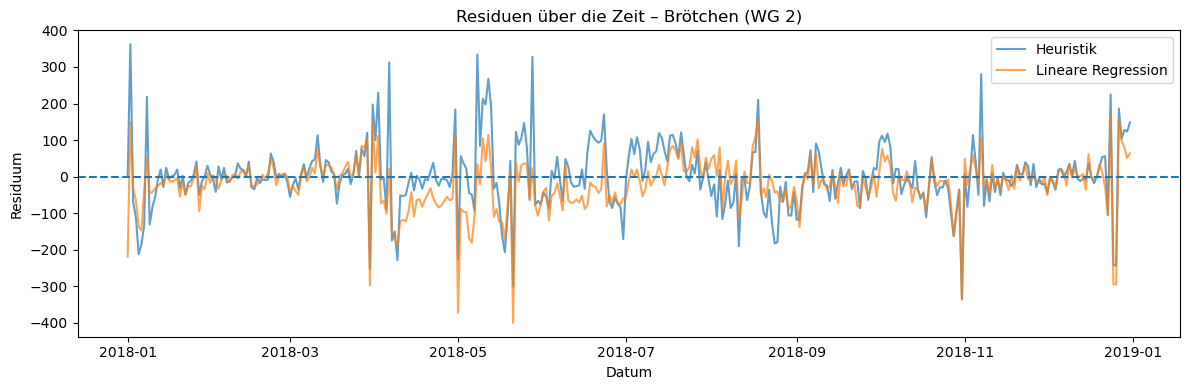

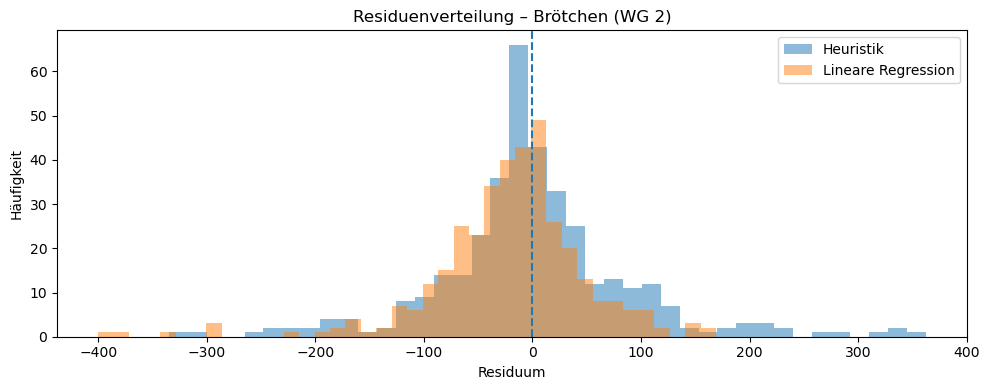

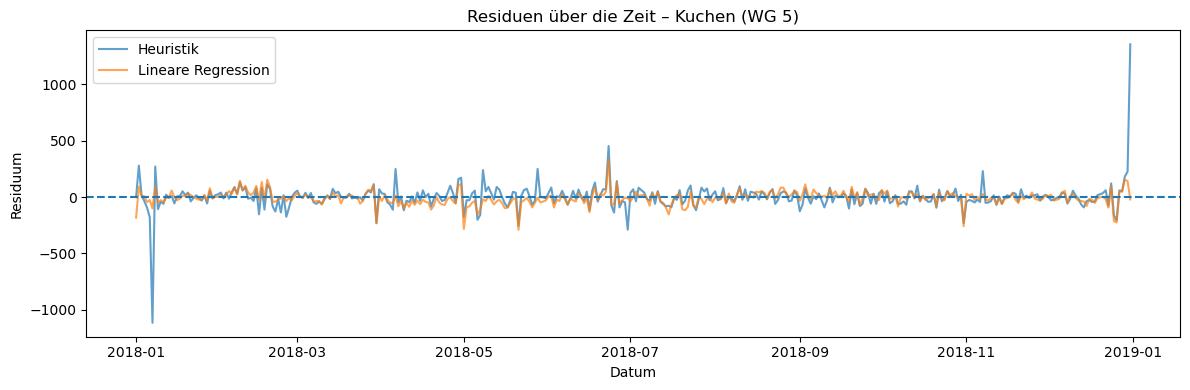

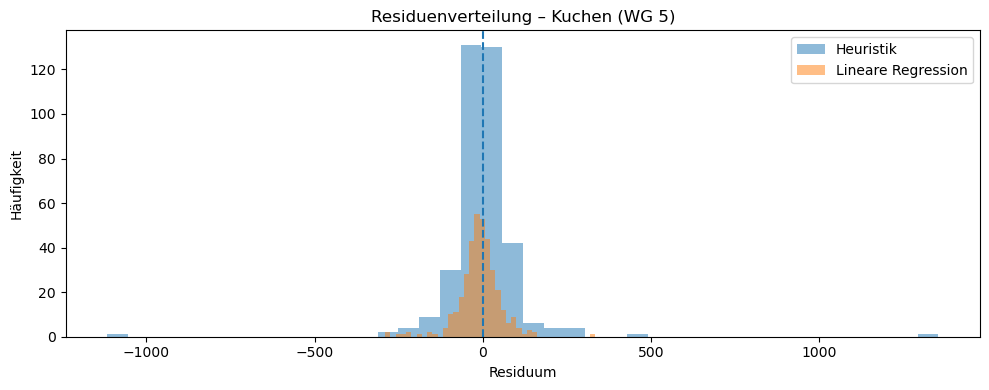

In [236]:
# Warengruppe 2 – Brötchen
df_test_WG2 = df_test[df_test["Warengruppe_num"] == 2].copy()

df_test_WG2["resid_heuristik"] = (
    df_test_WG2["Umsatz"] - df_test_WG2["lag_1W"]
)

df_test_WG2["resid_lr"] = (
    df_test_WG2["Umsatz"] - y_pred_lr_WG2
)

# Residuen über die Zeit
plt.figure(figsize=(12, 4))
plt.plot(df_test_WG2["Datum"], df_test_WG2["resid_heuristik"], label="Heuristik", alpha=0.7)
plt.plot(df_test_WG2["Datum"], df_test_WG2["resid_lr"], label="Lineare Regression", alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Residuen über die Zeit – Brötchen (WG 2)")
plt.xlabel("Datum")
plt.ylabel("Residuum")
plt.legend()
plt.tight_layout()
plt.show()

# Residuenverteilung
plt.figure(figsize=(10, 4))
plt.hist(df_test_WG2["resid_heuristik"], bins=40, alpha=0.5, label="Heuristik")
plt.hist(df_test_WG2["resid_lr"], bins=40, alpha=0.5, label="Lineare Regression")
plt.axvline(0, linestyle="--")
plt.title("Residuenverteilung – Brötchen (WG 2)")
plt.xlabel("Residuum")
plt.ylabel("Häufigkeit")
plt.legend()
plt.tight_layout()
plt.show()

# Warengruppe 5 – Kuchen
df_test_WG5 = df_test[df_test["Warengruppe_num"] == 5].copy()

df_test_WG5["resid_heuristik"] = (
    df_test_WG5["Umsatz"] - df_test_WG5["lag_1W"]
)

df_test_WG5["resid_lr"] = (
    df_test_WG5["Umsatz"] - y_pred_lr_WG5
)

# Residuen über die Zeit
plt.figure(figsize=(12, 4))
plt.plot(df_test_WG5["Datum"], df_test_WG5["resid_heuristik"], label="Heuristik", alpha=0.7)
plt.plot(df_test_WG5["Datum"], df_test_WG5["resid_lr"], label="Lineare Regression", alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Residuen über die Zeit – Kuchen (WG 5)")
plt.xlabel("Datum")
plt.ylabel("Residuum")
plt.legend()
plt.tight_layout()
plt.show()

# Residuenverteilung
plt.figure(figsize=(10, 4))
plt.hist(df_test_WG5["resid_heuristik"], bins=40, alpha=0.5, label="Heuristik")
plt.hist(df_test_WG5["resid_lr"], bins=40, alpha=0.5, label="Lineare Regression")
plt.axvline(0, linestyle="--")
plt.title("Residuenverteilung – Kuchen (WG 5)")
plt.xlabel("Residuum")
plt.ylabel("Häufigkeit")
plt.legend()
plt.tight_layout()
plt.show()

### Diskussion der Residuen

Für die **Warengruppe 2 (Brötchen)** fällt im Zeitverlauf der Residuen auf, dass es längere Phasen mit größeren Abweichungen gibt, und zwar für beide betrachteten Prognose-Modelle. Die Verteilung der Residuen ist ähnlich breit, wobei die lineare Regression offenbar den Umsatz systematisch zu hoch vorhersagt.

Für die **Warengruppe 5 (Kuchen)** zeigen sich die Residuen im Zeitverlauf zum Großteil wie ein zufälliges Rauschen um die Nulllinie. Lediglich für die Heuristik gibt es zwei extreme Werte, eine positive und eine negative Abweichung von tatsächlichem und prognostiziertem Umsatz. Das stark positive Residum am letzten Tag des Jahres ist auf den unterschätzten Umsatz für Silvester zurückzuführen. Die starken Abweichungen der Heuristik verzerren die Darstellung der Residuenverteilung. Hier lohnt es sich, tiefer einzusteigen und die Modelle zu erweitern, um die Prognosegüte zu erhöhen.


## 6. Reflexion und Ausblick

Im Rahmen der Analyse traten mehrere typische Herausforderungen der Zeitreihen- und Umsatzprognose auf. Eine zentrale Schwierigkeit bestand in der starken **Heterogenität der Warengruppen**. Während die Umsätze für Brötchen relativ stabilen Wochenmustern folgen, zeigen die Kuchenumsätze eine deutlich höhere Volatilität sowie ausgeprägte Ausreißer an einzelnen Tagen. Diese Unterschiede machten es notwendig, separate Modelle je Warengruppe zu betrachten, da ein gemeinsames Modell die jeweiligen Charakteristika nicht adäquat abbilden konnte.

Eine weitere Herausforderung ergab sich aus der Modellierung von **Sonderereignissen**. Die einfache Heuristik auf Basis des Vorwochenumsatzes versagte insbesondere an Tagen mit atypischem Nachfrageverhalten, wie etwa an Silvester. Durch die Einführung zusätzlicher Kalender-Features (z. B. Dummy-Variable für Silvester) konnte dieses Problem teilweise adressiert werden, was sich insbesondere bei der Warengruppe Kuchen in einer deutlichen Verbesserung der Prognosegüte widerspiegelte.

Trotz dieser Erweiterungen bleiben die betrachteten Modelle vergleichsweise einfach. Die lineare Regression ist zwar gut interpretierbar und reduziert extreme Prognosefehler, sie ist jedoch auf lineare Zusammenhänge beschränkt und kann komplexe Interaktionen zwischen Features nur eingeschränkt abbilden.

Zur weiteren Verbesserung der Prognosegüte bieten sich mehrere Ansätze an. Auf der Feature-Ebene könnten zusätzliche zeitliche Merkmale wie Monat, Kalenderwoche, Feiertage oder Brückentage integriert werden. Auch die Verwendung mehrerer Lag-Variablen (z. B. Umsatz der letzten zwei oder drei Wochen) könnte helfen, längerfristige Trends besser zu erfassen.

Auf Modell-Ebene stellen nichtlineare Verfahren eine naheliegende Erweiterung dar. Entscheidungsbaum-basierte Modelle wie Random Forests können Interaktionen automatisch lernen und sind robuster gegenüber Ausreißern. Darüber hinaus eignen sich neuronale Netze – insbesondere rekurrente Architekturen wie LSTM – zur expliziten Modellierung zeitlicher Abhängigkeiten, erfordern jedoch eine sorgfältige Feature-Skalierung und Modellvalidierung.

Zusammenfassend zeigt die Analyse, dass bereits einfache **Baseline**-Modelle wertvolle Erkenntnisse liefern können, zugleich aber auch deutlich machen, wo ihre Grenzen liegen.

## Feuer frei für den Hackathon!!!

Genau an dieser Stelle setzt die Data Challenge an: Jetzt seid Ihr aufgefordert, durch Anreicherung der Daten, gezieltes Feature Engineering und den Einsatz geeigneter Modelle die Prognosegüte systematisch zu verbessern.
Auf Euch wartet... **Ruhm und Ehre!** :-)
